## Olympic swimming history (1912 - 2020)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy

df = pd.read_csv("C:\\Users\\peraz\\Code\\dataAnalysis\\swimming\\Olympic_Swimming_Results_1912to2020.csv")

### Data exploration

In [3]:
print("Rows, columns : ", df.shape)
df.info()
print(df.describe())

Rows, columns :  (4359, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4359 entries, 0 to 4358
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Location              4359 non-null   object
 1   Year                  4359 non-null   int64 
 2   Distance (in meters)  4359 non-null   object
 3   Stroke                4359 non-null   object
 4   Relay?                4359 non-null   int64 
 5   Gender                4359 non-null   object
 6   Team                  4359 non-null   object
 7   Athlete               4345 non-null   object
 8   Results               4331 non-null   object
 9   Rank                  4359 non-null   int64 
dtypes: int64(3), object(7)
memory usage: 340.7+ KB
              Year       Relay?         Rank
count  4359.000000  4359.000000  4359.000000
mean   1982.936453     0.169764     3.164946
std      26.928344     0.375468     1.189715
min    1912.000000     0.000000  

### Data cleaning

In [4]:
## convert time (results) min:sec.dec into floats to be better in conversion
import datetime as dt
def convert_time(t):
    try:
        if pd.isna(t): #if value is empty (NaN) -> not taken 
            return None
        
        parts = str(t).split(":") # convert into string
        # "52.91" → ["52.91"]
        # "1:54.91" → ["1", "54.91"]
        # "1:02:34.56" → ["1", "02", "34.56"]
        
        # each part converted into floats
        parts = [float(p) for p in parts]
        # ["1", "54.91"] → [1.0, 54.91]
        
        # Case:
        # ss
        if len(parts) == 1:
            return parts[0]  #"52.91" → 52.91
        
        # mm:ss
        elif len(parts) == 2:
            return parts[0]*60 + parts[1]  #"1:54.91" → 1*60 + 54.91 = 114.91
        
        # hh:mm:ss
        elif len(parts) == 3:
            return parts[0]*3600 + parts[1]*60 + parts[2]  # "1:02:34.56" → 1*3600 + 2*60 + 34.56 = 3754.56
    
        else:
            return None

    except:
        return None

df["Results"] = df["Results"].apply(convert_time)

#keep only the swimmers with medals / finished
df["Rank"] = pd.to_numeric(df["Rank"], errors="coerce")
df = df[df["Rank"] != 5]
rank_map = {
    0: "DNS / DNF",
    1: "Gold",
    2: "Silver",
    3: "Bronze",
    4: "No Medal",
}
df["Rank"] = df["Rank"].map(rank_map)


# Clean the distance (without the m + converting it in float)
df["Distance_clean"] = df["Distance (in meters)"].str.replace("*","x", regex=False)

#Separate relay and individual races
mask_relay = df["Relay?"] == 1
mask_indiv = df["Relay?"] == 0


#Get distance in float -> for the individuals
df.loc[mask_indiv, "Distance_float"] = (
    df.loc[mask_indiv, "Distance_clean"]
    .str.replace("m", "", regex=False)
    .astype(float)
)

#Get distance in float -> For the relays
def convert_relay(d):
    try:
        a, b = d.split("x")
        return float(a) * float(b)
    except:
        return None

df.loc[mask_relay, "Distance_float"] = (
    df.loc[mask_relay, "Distance_clean"]
    .apply(convert_relay)
)
df = df.dropna() #cleaning df by dropping all NaN values
df.head()



,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Team,Athlete,Results,Rank,Distance_clean,Distance_float
0,Tokyo,2020,100m,Backstroke,0,Men,ROC,Evgeny Rylov,51.98,Gold,100m,100.0
1,Tokyo,2020,100m,Backstroke,0,Men,ROC,Kliment Kolesnikov,52.00,Silver,100m,100.0
2,Tokyo,2020,100m,Backstroke,0,Men,USA,Ryan Murphy,52.19,Bronze,100m,100.0
3,Tokyo,2020,100m,Backstroke,0,Men,ITA,Thomas Ceccon,52.30,No Medal,100m,100.0
4,Tokyo,2020,100m,Backstroke,0,Men,CHN,Jiayu Xu,52.51,No Medal,100m,100.0


### Descriptive analysis & visualisations

#### Performance over time

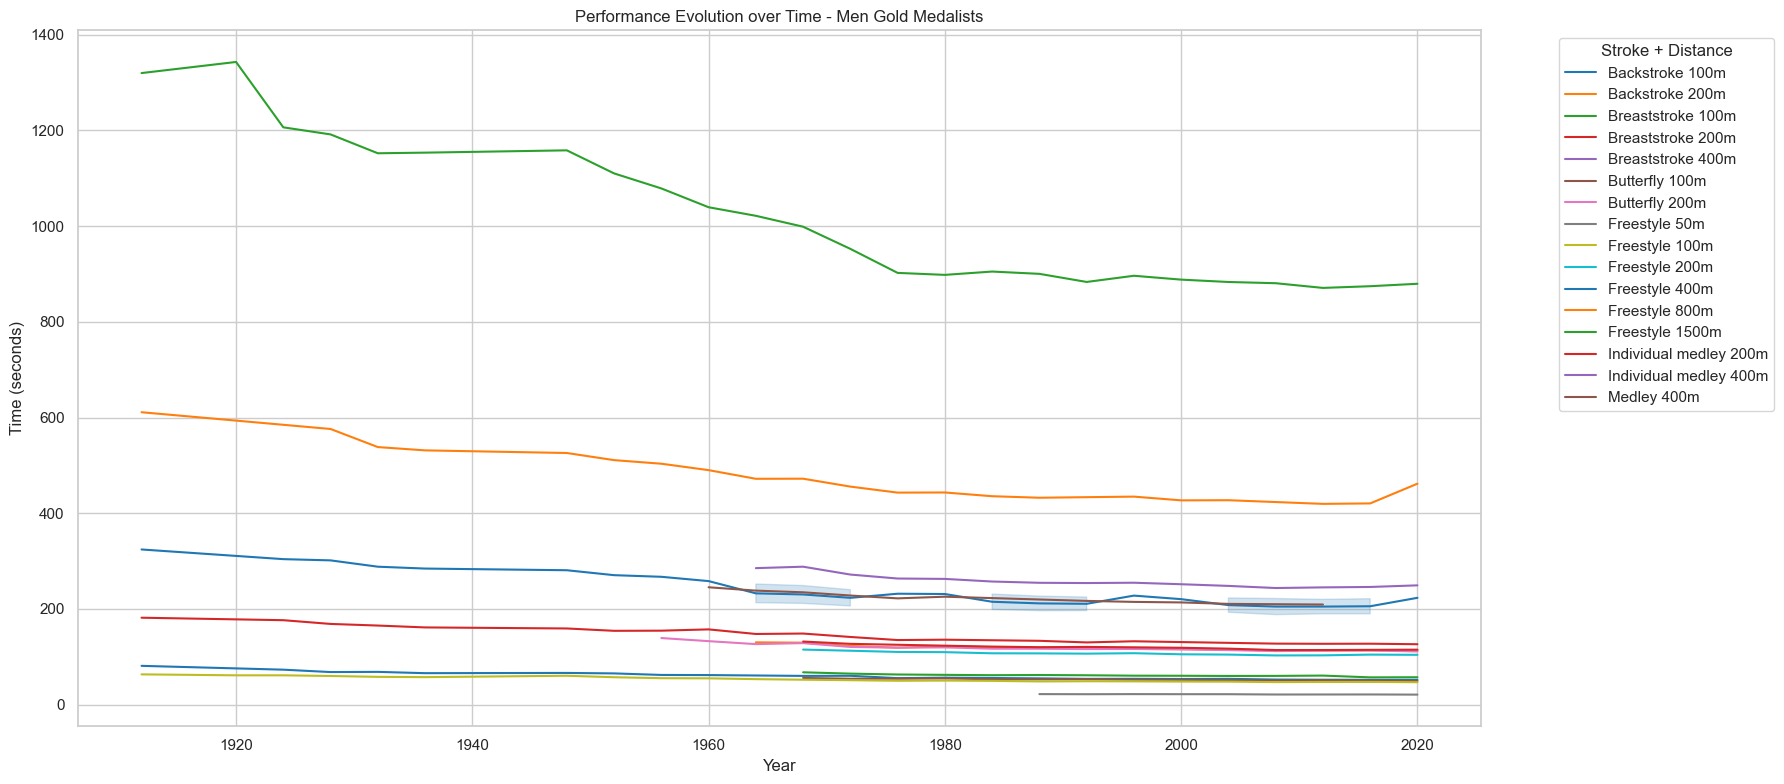

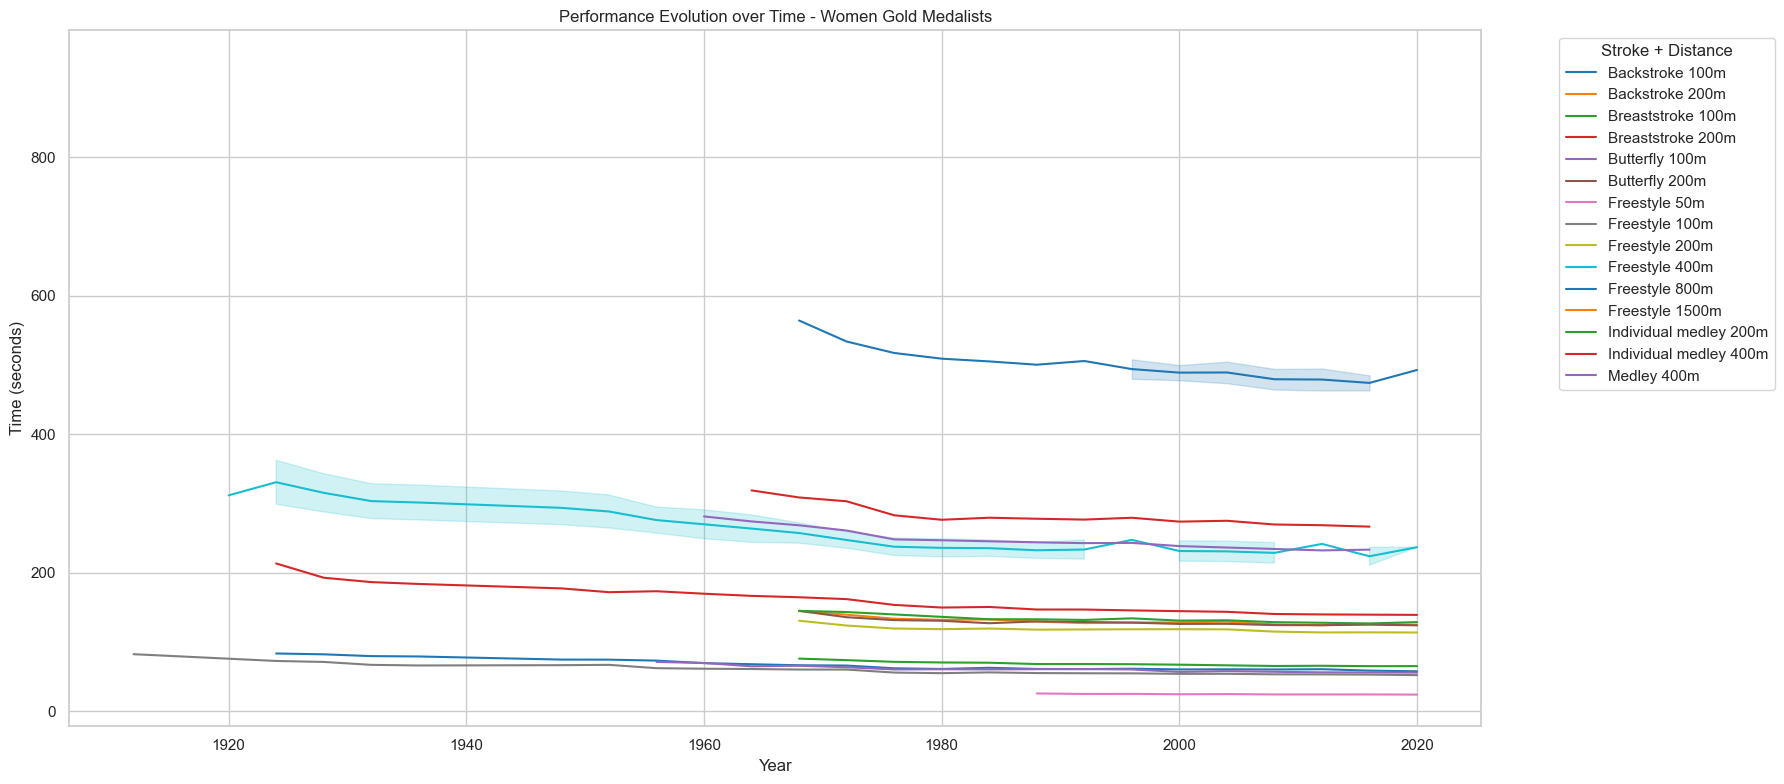

In [5]:
# Performance evolution over time

#split between men and women performances
df_men = df[df["Gender"]== "Men"] #df for men
df_women = df[df["Gender"]== "Women"] # df for women

df_gold_men = df_men[df_men["Rank"]=="Gold"]
df_gold_women = df_women[df_women["Rank"]=="Gold"]

sns.set(style="whitegrid",palette="tab10")

def plot_performance(df, gender):
    plt.figure(figsize=(18,8))
    
    #Group by stroke and gender
    strokes = df["Stroke"].unique()
    distances = df["Distance_float"].unique()
    
    for stroke in strokes:
        for dist in sorted(distances):
            df_sub = df[(df["Stroke"]==stroke) & (df["Distance_float"]==dist)]
            if len(df_sub) > 0:
                # plot year vs result
                sns.lineplot(
                    data=df_sub,
                    x="Year",
                    y="Results",
                    label=f"{stroke} {int(dist)}m"
                )
    
    plt.title(f"Performance Evolution over Time - {gender} Gold Medalists")
    plt.xlabel("Year")
    plt.ylabel("Time (seconds)")
    plt.legend(title="Stroke + Distance", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    # Create the graphics directory if it doesn't already exist
    import os
    os.makedirs('images', exist_ok=True)
    
    # Dynamically save the file using the gender parameter
    plt.savefig(f'images/{gender.lower()}_over_time.png', dpi=300, bbox_inches='tight')
    plt.show()


plot_performance(df_gold_men, "Men")
plot_performance(df_gold_women, "Women")





In [6]:
import plotly.graph_objects as go

#sort the values
df_sorted = df_gold_men.sort_values("Year").reset_index(drop=True)
years = sorted(df_sorted["Year"].unique())
distances = sorted(df_sorted["Distance_float"].unique())

print("Detected distances :", distances)   #verify distance detected

dict_color = {
    50:   "#e63946",
    100:  "#457b9d",
    200:  "#2a9d8f",
    400:  "#e9c46a",
    800:  "#9b5de5",
    1500: "#f4a261"
}

fallback_colors = ["#264653", "#e76f51", "#a8dadc", "#06d6a0", "#118ab2"]

def get_color(dist, idx):
    key = int(dist)
    if key in dict_color:
        return dict_color[key]
    return fallback_colors[idx % len(fallback_colors)]

# create trails of a frame
def make_traces(df_up_to_year):
    traces = []
    for i, dist in enumerate(distances):
        df_d = df_up_to_year[df_up_to_year["Distance_float"] == dist].sort_values("Year")
        label = df_d["Distance_clean"].iloc[0] if len(df_d) else str(int(dist)) + "m"
        color = get_color(dist, i)
        traces.append(go.Scatter(
            x=df_d["Year"],
            y=df_d["Results"],
            mode="lines+markers",  # no more text
            name=label,
            line=dict(color=color, width=2),
            marker=dict(color=color, size=8),
        ))
    return traces

#Inital frame
initial_traces = make_traces(df_sorted[df_sorted["Year"] <= years[0]])

# Other frames
frames = []
for year in years:
    df_frame = df_sorted[df_sorted["Year"] <= year]
    frames.append(go.Frame(
        data=make_traces(df_frame),
        name=str(year),
        layout=go.Layout(title_text=f"Olympic Gold Medals – Men's Swimming ({year})")
    ))

# Slider
sliders = [{
    "active": 0,
    "steps": [
        {
            "args": [[str(year)], {
                "frame": {"duration": 600, "redraw": True},
                "mode": "immediate",
                "transition": {"duration": 400}
            }],
            "label": str(year),
            "method": "animate"
        }
        for year in years
    ],
    "x": 0.05, "xanchor": "left",
    "y": -0.07, "yanchor": "top",
    "len": 0.9,
    "currentvalue": {"prefix": "Year: ", "visible": True, "xanchor": "center"},
    "transition": {"duration": 400}
}]


# figure
fig = go.Figure(
    data=initial_traces,
    frames=frames,
    layout=go.Layout(
        title="Olympic Gold Medals – Men's Swimming",
        width=1200,   # ← width
        height=750,   # ← height
        xaxis=dict(
            title="Year",
            range=[years[0] - 2, years[-1] + 2],
            showgrid=False,
            tickmode="array",
            tickvals=years,
            tickangle=45
        ),
        yaxis=dict(
            title="Time (seconds)",
            range=[df_sorted["Results"].min() * 0.95,
                   df_sorted["Results"].max() * 1.05],
            showgrid=True,
            autorange="reversed"
        ),
        legend=dict(title="Distance", x=1.01, y=1),
        sliders=sliders,
        margin=dict(b=100), 
        hovermode="x unified"
    )
)
fig.write_html("swimming_men.html")
fig.show()

Detected distances : [np.float64(50.0), np.float64(100.0), np.float64(200.0), np.float64(400.0), np.float64(800.0), np.float64(1500.0)]


In [7]:
import plotly.graph_objects as go

#sort the values
df_sorted = df_gold_women.sort_values("Year").reset_index(drop=True)
years = sorted(df_sorted["Year"].unique())
distances = sorted(df_sorted["Distance_float"].unique())

print("Detected distances :", distances)   #verify distance detected

dict_color = {
    50:   "#e63946",
    100:  "#457b9d",
    200:  "#2a9d8f",
    400:  "#e9c46a",
    800:  "#9b5de5",
    1500: "#f4a261"
}

fallback_colors = ["#264653", "#e76f51", "#a8dadc", "#06d6a0", "#118ab2"]

def get_color(dist, idx):
    key = int(dist)
    if key in dict_color:
        return dict_color[key]
    return fallback_colors[idx % len(fallback_colors)]

# create trails of a frame
def make_traces(df_up_to_year):
    traces = []
    for i, dist in enumerate(distances):
        df_d = df_up_to_year[df_up_to_year["Distance_float"] == dist].sort_values("Year")
        label = df_d["Distance_clean"].iloc[0] if len(df_d) else str(int(dist)) + "m"
        color = get_color(dist, i)
        traces.append(go.Scatter(
            x=df_d["Year"],
            y=df_d["Results"],
            mode="lines+markers",  # no more text
            name=label,
            line=dict(color=color, width=2),
            marker=dict(color=color, size=8),
        ))
    return traces

#Inital frame
initial_traces = make_traces(df_sorted[df_sorted["Year"] <= years[0]])

# Other frames
frames = []
for year in years:
    df_frame = df_sorted[df_sorted["Year"] <= year]
    frames.append(go.Frame(
        data=make_traces(df_frame),
        name=str(year),
        layout=go.Layout(title_text=f"Olympic Gold Medals – Women's Swimming ({year})") 
    ))

# Slider
sliders = [{
    "active": 0,
    "steps": [
        {
            "args": [[str(year)], {
                "frame": {"duration": 600, "redraw": True},
                "mode": "immediate",
                "transition": {"duration": 400}
            }],
            "label": str(year),
            "method": "animate"
        }
        for year in years
    ],
    "x": 0.05, "xanchor": "left",
    "y": -0.07, "yanchor": "top",
    "len": 0.9,
    "currentvalue": {"prefix": "Year: ", "visible": True, "xanchor": "center"},
    "transition": {"duration": 400}
}]


# figure
fig = go.Figure(
    data=initial_traces,
    frames=frames,
    layout=go.Layout(
        title="Olympic Gold Medals – Women's Swimming",
        width=1200,   # ← width
        height=750,   # ← height
        xaxis=dict(
            title="Year",
            range=[years[0] - 2, years[-1] + 2],
            showgrid=False,
            tickmode="array",
            tickvals=years,
            tickangle=45
        ),
        yaxis=dict(
            title="Time (seconds)",
            range=[df_sorted["Results"].min() * 0.95,
                   df_sorted["Results"].max() * 1.05],
            showgrid=True,
            autorange="reversed"
        ),
        legend=dict(title="Distance", x=1.01, y=1),
        sliders=sliders,
        margin=dict(b=100), 
        hovermode="x unified"
    )
)

fig.show()
fig.write_html("swimming_women.html")

Detected distances : [np.float64(50.0), np.float64(100.0), np.float64(200.0), np.float64(400.0), np.float64(800.0), np.float64(1500.0)]


#### Gender gap analysis

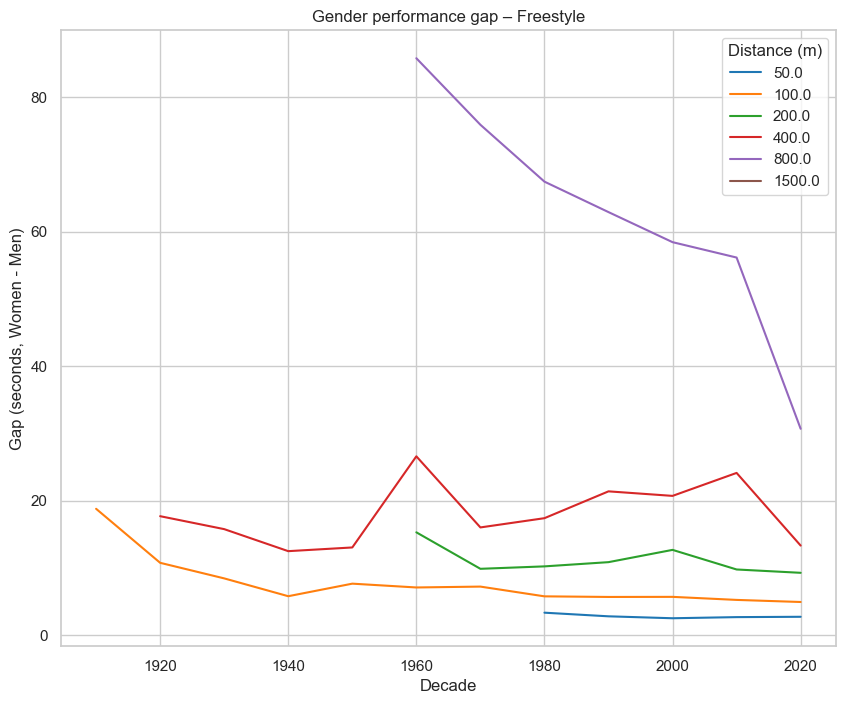

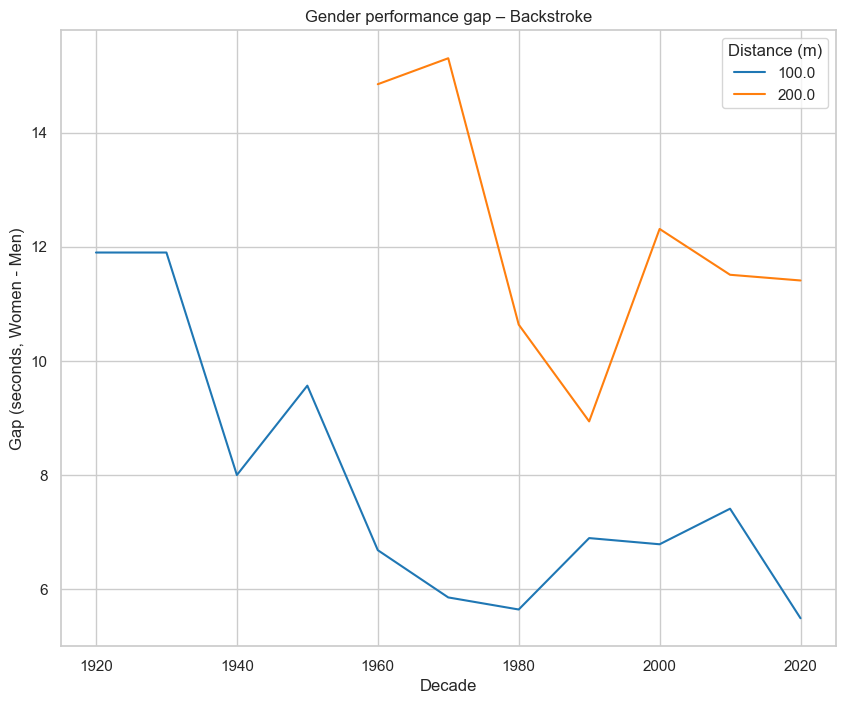

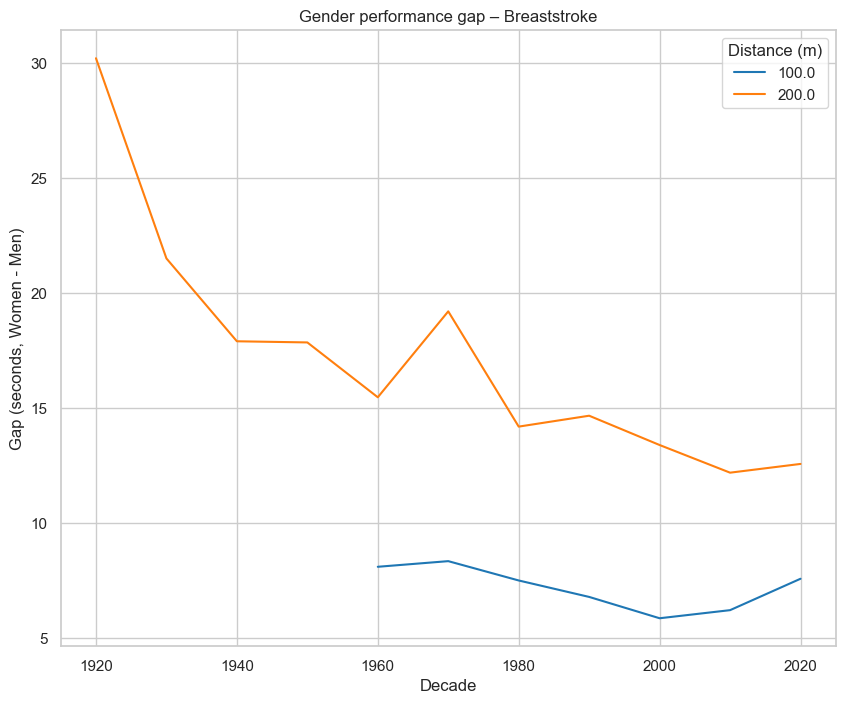

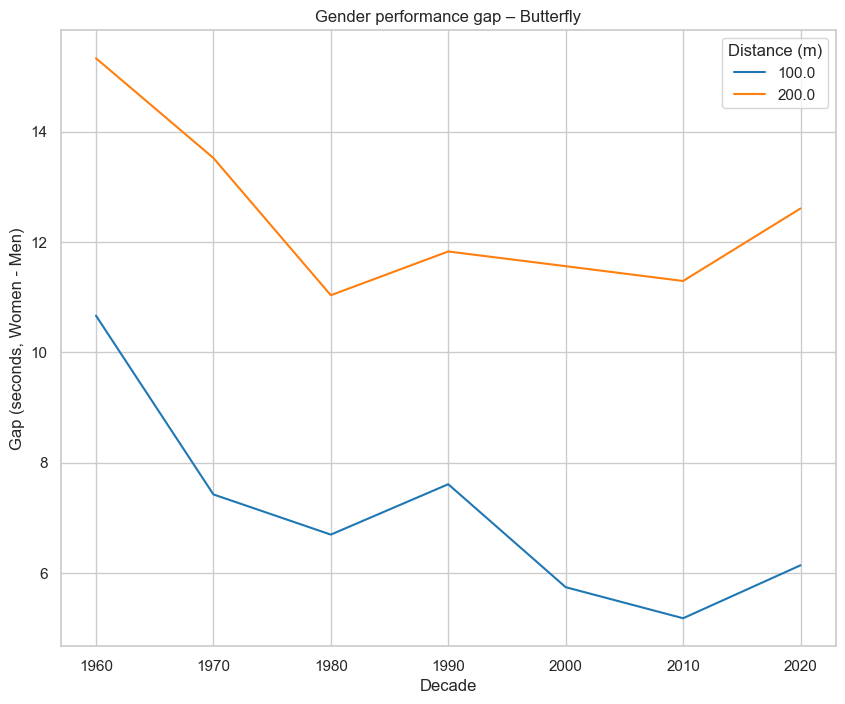

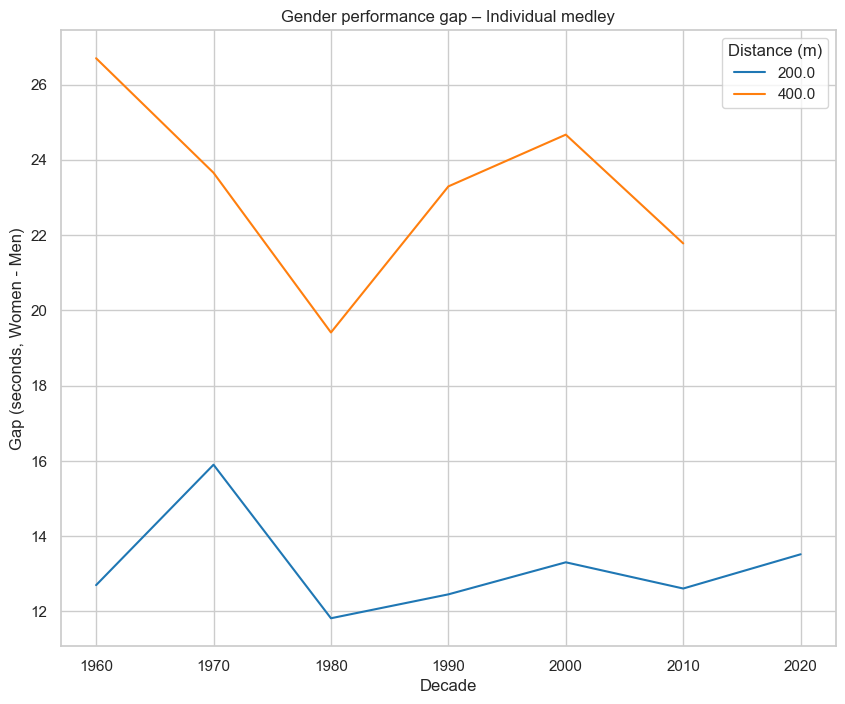

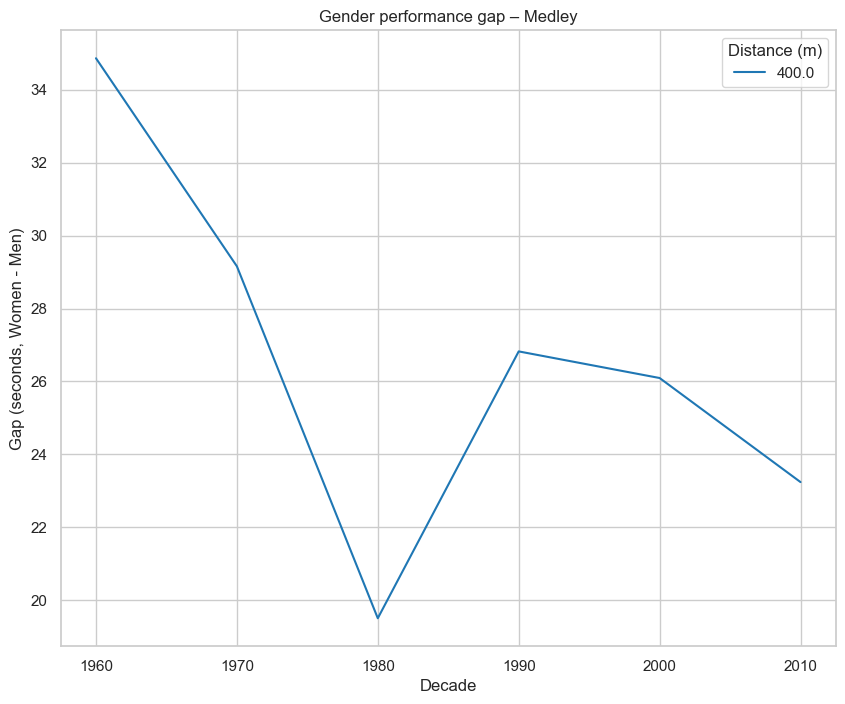

In [8]:
#df["Decade"] = (df["Year"]//10)*10

df_gold_men = df_gold_men.copy()
df_gold_women = df_gold_women.copy()

df_gold_men['Decade'] = (df_gold_men['Year'] // 10) * 10
df_gold_women['Decade'] = (df_gold_women['Year'] // 10) * 10

#merge to compare several distances
df_merge = pd.merge(
    df_gold_men,
    df_gold_women,
    on=['Stroke','Distance_float','Decade'],
    suffixes=('_men','_women')
)

df_merge['Gap'] = df_merge['Results_women'] - df_merge['Results_men']
df_gap = df_merge.groupby(['Decade','Stroke','Distance_float'])['Gap'].mean().reset_index()

strokes = df_gap['Stroke'].unique()

import os
os.makedirs('images', exist_ok=True)

for stroke in strokes:
    df_stroke = df_gap[df_gap['Stroke'] == stroke]
    n_distances = df_stroke['Distance_float'].nunique()
    
    plt.figure(figsize=(10, 8))
    sns.lineplot(
        data=df_stroke,
        x='Decade',
        y='Gap',
        hue='Distance_float',
        markers=True,
        dashes=False,
        palette=sns.color_palette("tab10", n_colors=n_distances)
    )
    plt.title(f'Gender performance gap – {stroke}')
    plt.ylabel('Gap (seconds, Women - Men)')
    plt.xlabel('Decade')
    plt.legend(title='Distance (m)')
    
    # Sauvegarde du graphique dans le dossier images
    plt.savefig(f'images/gender_performance_gap_{stroke}.png', dpi=300, bbox_inches='tight')
    
    plt.show()

#### Country dominance

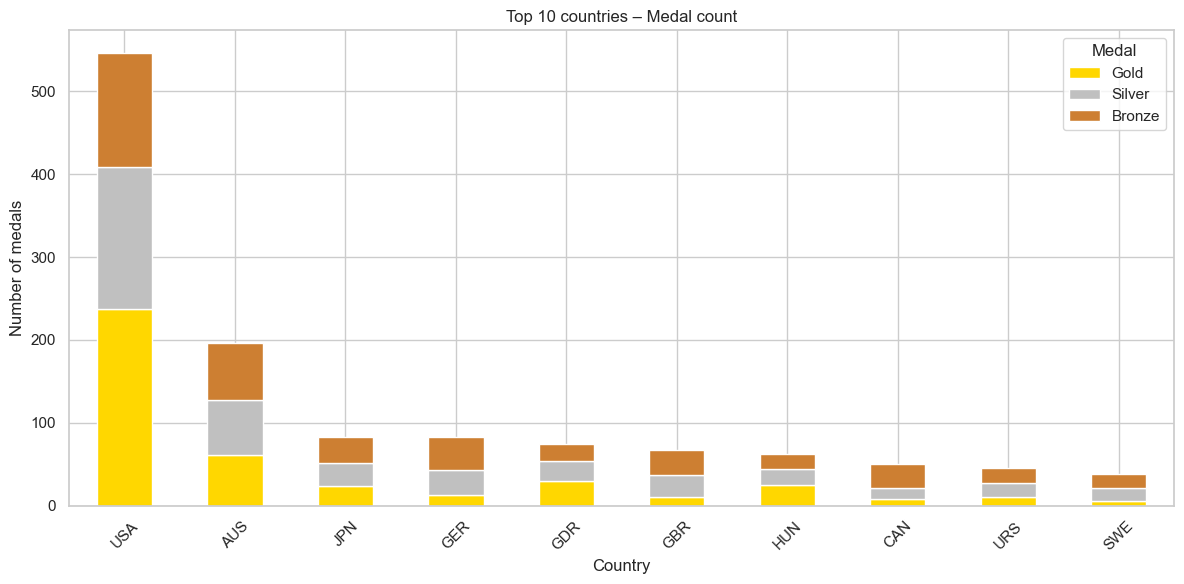

In [9]:
df['Decade'] = (df['Year'] // 10) * 10 

medal_counts = (
    df.groupby(['Team', 'Rank']) 
    .size()
    .reset_index(name='Count')
)

top10 = (
    medal_counts.groupby('Team')['Count']
    .sum()
    .nlargest(10)
    .index
)

df_top10 = medal_counts[medal_counts['Team'].isin(top10)]
df_pivot = df_top10.pivot_table(index='Team', columns='Rank', values='Count', fill_value=0)
#row = country
#column = gold/silver/bronze
#value = medals sum count
df_pivot = df_pivot.reindex(columns=['Gold', 'Silver', 'Bronze'])
df_pivot = df_pivot.loc[df_pivot.sum(axis=1).sort_values(ascending=False).index] #sort countries from highest to most little count of medals


df_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color=['#FFD700', '#C0C0C0', '#CD7F32']
)
plt.title('Top 10 countries – Medal count')
plt.ylabel('Number of medals')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.legend(title='Medal')
plt.tight_layout()
plt.savefig("images/hist_medals_top10_countries.png",dpi=300, bbox_inches='tight' )
plt.show()

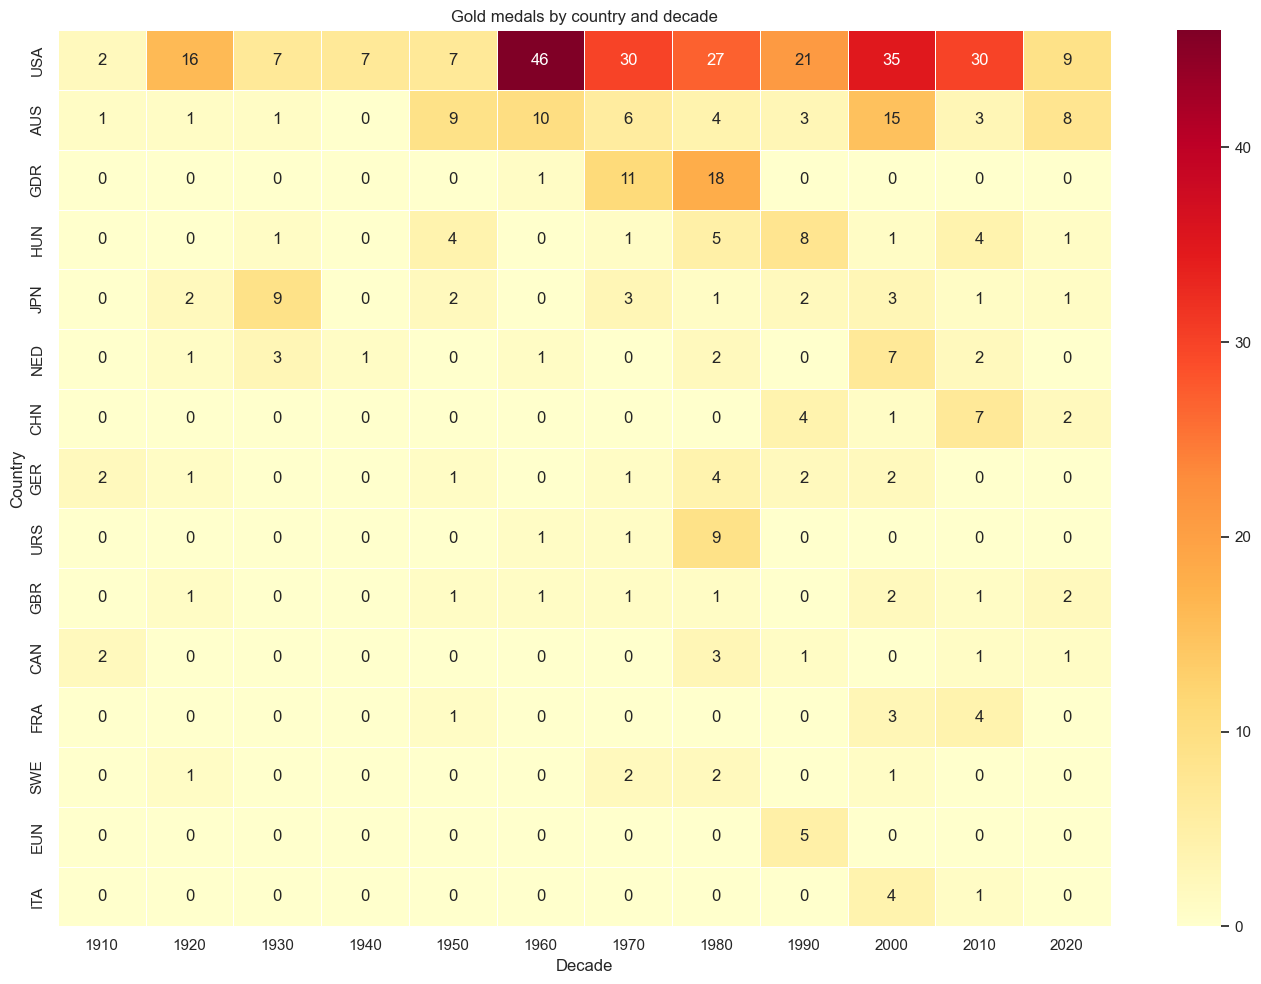

In [10]:
# Heatmap to see the top 15 countries with gold medals

df_gold = df[df["Rank"]=="Gold"]
heatmap_data = (
    df_gold.groupby(['Team','Decade'])
    .size()
    .reset_index(name='Gold_count')
)
top15 = (
    heatmap_data.groupby('Team')['Gold_count']
    .sum()
    .nlargest(15)
    .index
)

df_heatmap = heatmap_data[heatmap_data['Team'].isin(top15)]
df_heatmap_pivot = df_heatmap.pivot_table(index='Team', columns='Decade', values='Gold_count', fill_value=0)
df_heatmap_pivot = df_heatmap_pivot.astype(int) 
#sort by descending values
df_heatmap_pivot = df_heatmap_pivot.loc[df_heatmap_pivot.sum(axis=1).sort_values(ascending=False).index]
plt.figure(figsize=(14, 10))
sns.heatmap(
    df_heatmap_pivot,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white'
)
plt.title('Gold medals by country and decade')
plt.ylabel('Country')
plt.xlabel('Decade')
plt.tight_layout()
plt.savefig("images/heatmap_medals_countries.png",dpi=300, bbox_inches='tight' )
plt.show()

#### Stroke & distance analysis

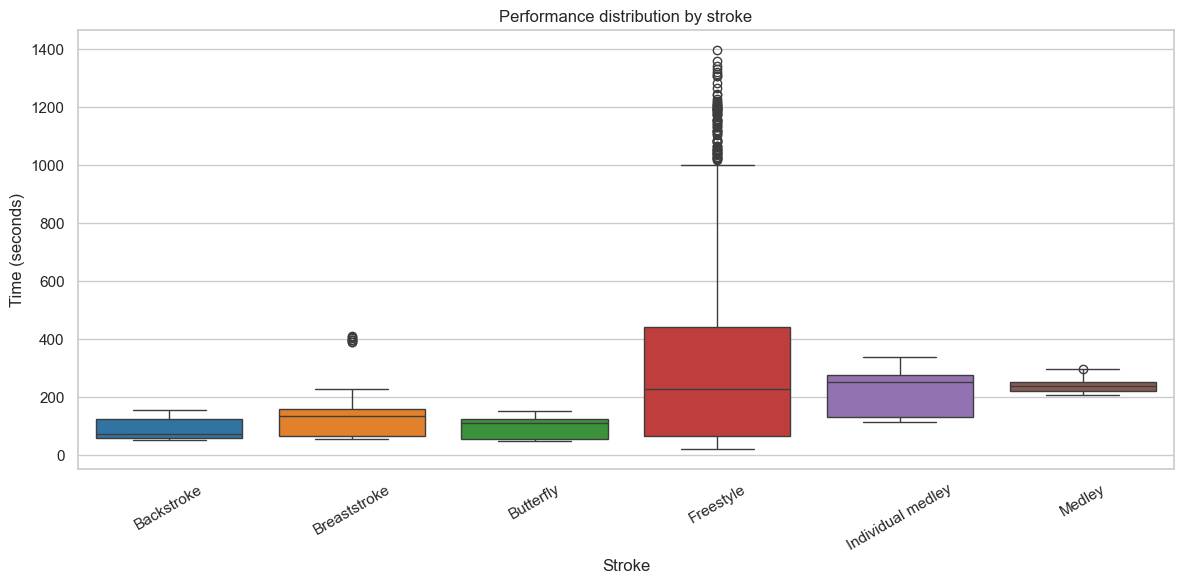

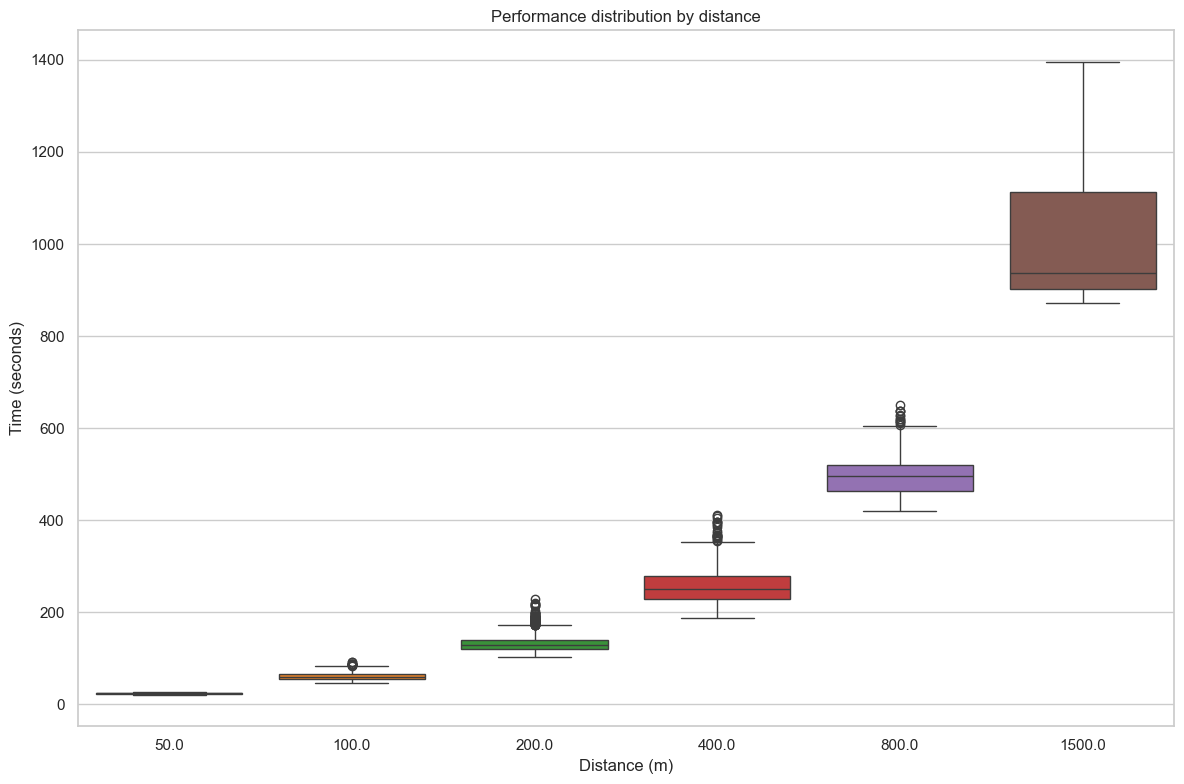

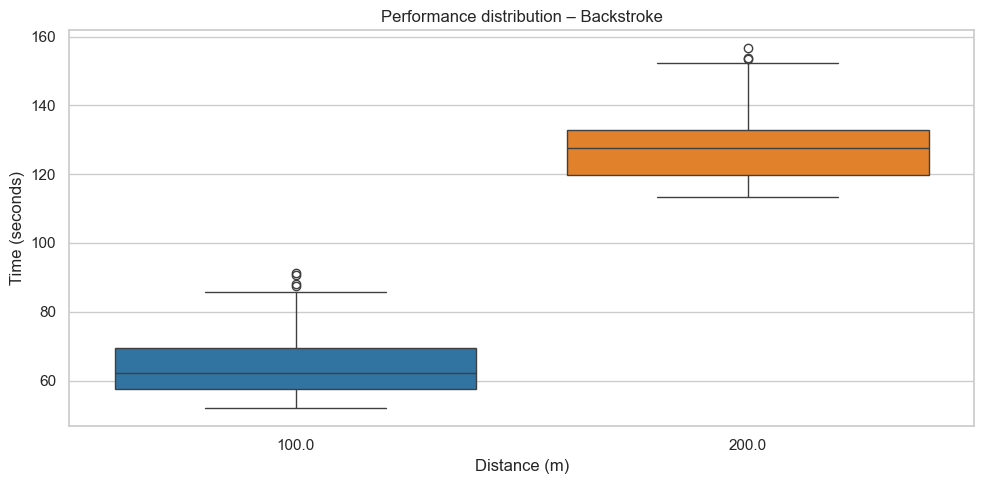

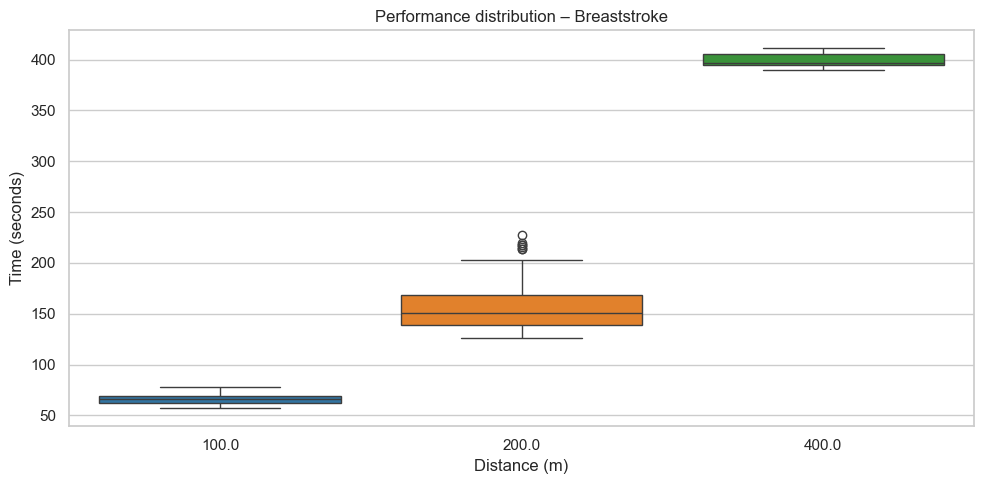

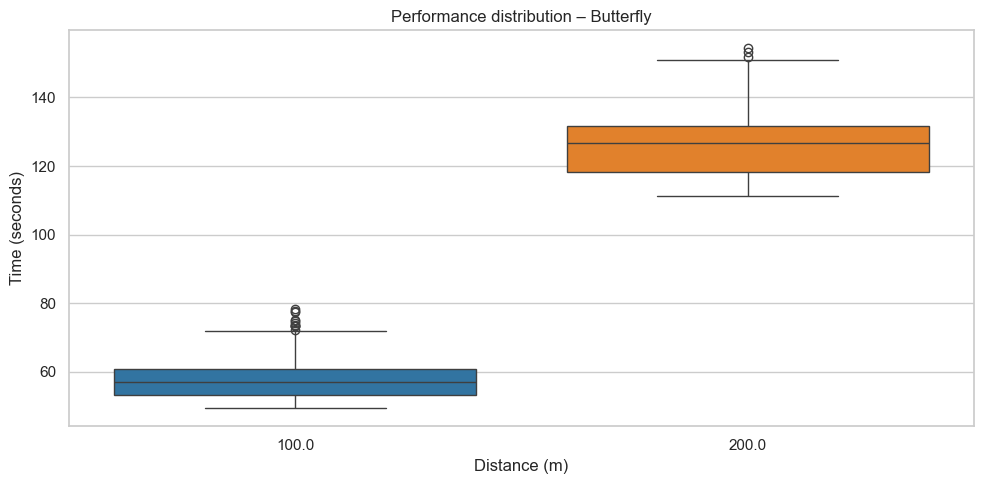

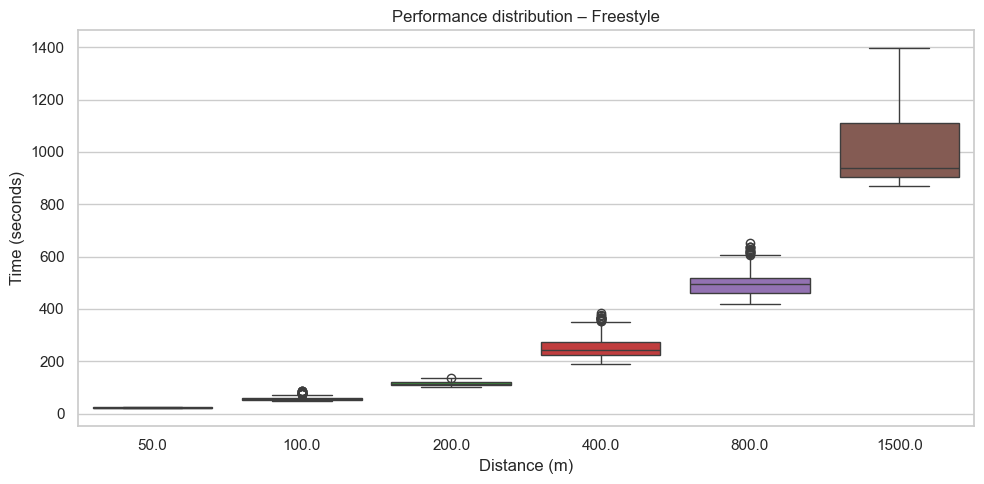

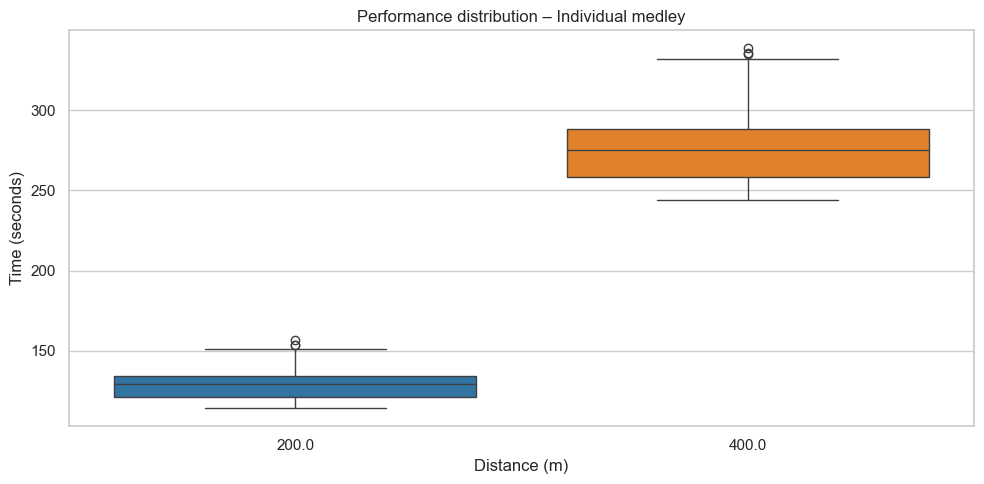

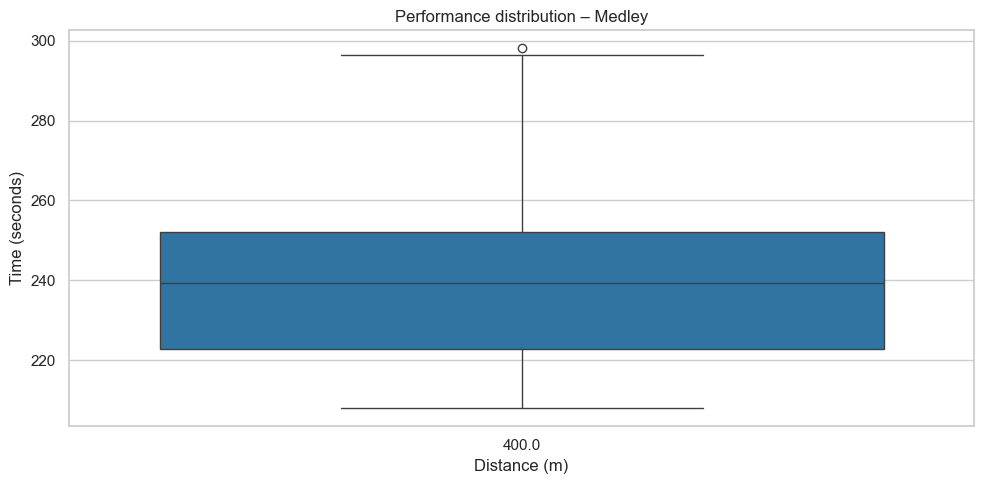

In [11]:
# stroke analysis

strokes = df["Stroke"].unique()
distances = sorted(df["Distance_float"].unique())


# boxplot par stroke
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x="Stroke",
    y="Results",
    palette="tab10",
    hue="Stroke",    
    dodge=False         # no offset if hue = x
)
plt.legend([],[], frameon=False)  # no label
plt.title("Performance distribution by stroke")
plt.ylabel("Time (seconds)")
plt.xlabel("Stroke")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


#boxplot time & distance
plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df,
    x="Distance_float",
    y="Results",
    palette="tab10",
    hue="Distance_float",  #x linked to hue
    dodge=False
)
plt.legend([],[], frameon=False)
plt.title("Performance distribution by distance")
plt.ylabel("Time (seconds)")
plt.xlabel("Distance (m)")
plt.tight_layout()
plt.show()

#boxplot per stroke (& distance)
for stroke in strokes:
    df_stroke = df[df["Stroke"] == stroke]
    
    plt.figure(figsize=(10, 5))
    sns.boxplot(
        data=df_stroke,
        x="Distance_float",
        y="Results",
        palette="tab10",
        hue="Distance_float",
        dodge=False
    )
    plt.legend([],[], frameon=False)
    plt.title(f"Performance distribution – {stroke}")
    plt.ylabel("Time (seconds)")
    plt.xlabel("Distance (m)")
    plt.tight_layout()
    plt.show()

### Statistical testing

In [12]:
# test if swimmers are faster after ban of "super-suits" in january 2010 by world aquatics

#print(df['Year'].dtype) -> int

# delete NaN or invalid values
df = df[df['Year'].notna()]

# # Vérifier
#print(df['Year'].head())
df_before_2010 = df[df['Year'] < 2010]
df_after_2010  = df[df['Year'] >= 2010]

#T-Test (student test)
#H0 : no difference before & after 2010
#H1 : there is a difference


from scipy.stats import ttest_ind
before = df_before_2010['Results']
after  = df_after_2010['Results']
t_stat, p_value = ttest_ind(before, after, equal_var=False) 

print("t-statistic:", t_stat)
print("p-value:", p_value)

#if p_value < 0.05 there is a difference


t-statistic: 3.4416230741177203
p-value: 0.0005991209863869003


In [13]:
for stroke in df['Stroke'].unique():
    for dist in df['Distance_float'].unique():
        b = df_before_2010[(df_before_2010['Stroke']==stroke) & (df_before_2010['Distance_float']==dist)]['Results']
        a = df_after_2010[(df_after_2010['Stroke']==stroke) & (df_after_2010['Distance_float']==dist)]['Results']
        if len(b) > 1 and len(a) > 1:
            t_stat, p_val = ttest_ind(b, a, equal_var=False)
            print(f"{stroke} {dist}m : t={t_stat:.2f}, p={p_val:.10f}")

Backstroke 100.0m : t=14.62, p=0.0000000000
Backstroke 200.0m : t=6.89, p=0.0000000005
Breaststroke 100.0m : t=6.55, p=0.0000000030
Breaststroke 200.0m : t=17.21, p=0.0000000000
Butterfly 100.0m : t=8.83, p=0.0000000000
Butterfly 200.0m : t=6.58, p=0.0000000020
Freestyle 100.0m : t=13.34, p=0.0000000000
Freestyle 1500.0m : t=10.44, p=0.0000000000
Freestyle 200.0m : t=5.93, p=0.0000000415
Freestyle 400.0m : t=12.21, p=0.0000000000
Freestyle 50.0m : t=2.85, p=0.0053270063
Freestyle 800.0m : t=6.69, p=0.0000000004
Individual medley 200.0m : t=5.75, p=0.0000000867
Individual medley 400.0m : t=8.49, p=0.0000000000
Medley 400.0m : t=7.33, p=0.0000000023


In [14]:
for stroke in df['Stroke'].unique():
    for dist in df['Distance_float'].unique():
        
        before = df_before_2010[
            (df_before_2010['Stroke'] == stroke) & 
            (df_before_2010['Distance_float'] == dist)
        ]['Results'] #get the results before 2010
        
        after = df_after_2010[
            (df_after_2010['Stroke'] == stroke) & 
            (df_after_2010['Distance_float'] == dist)
        ]['Results'] #get the results after 2010
        
        if len(before) > 1 and len(after) > 1: 
            diff = before.mean() - after.mean()
            
            print(f"{stroke} {dist}m | before: {before.mean():.2f} | after: {after.mean():.2f} | diff: {diff:.2f}")

Backstroke 100.0m | before: 65.65 | after: 55.78 | diff: 9.87
Backstroke 200.0m | before: 128.91 | after: 121.39 | diff: 7.52
Breaststroke 100.0m | before: 66.98 | after: 62.69 | diff: 4.29
Breaststroke 200.0m | before: 158.52 | after: 132.65 | diff: 25.87
Butterfly 100.0m | before: 59.11 | after: 53.86 | diff: 5.26
Butterfly 200.0m | before: 127.73 | after: 120.46 | diff: 7.26
Freestyle 100.0m | before: 58.11 | after: 50.44 | diff: 7.67
Freestyle 1500.0m | before: 1029.49 | after: 904.06 | diff: 125.43
Freestyle 200.0m | before: 115.92 | after: 110.39 | diff: 5.53
Freestyle 400.0m | before: 256.49 | after: 223.89 | diff: 32.60
Freestyle 50.0m | before: 23.69 | after: 22.98 | diff: 0.71
Freestyle 800.0m | before: 502.51 | after: 470.51 | diff: 32.00
Individual medley 200.0m | before: 130.58 | after: 123.47 | diff: 7.12
Individual medley 400.0m | before: 279.92 | after: 259.83 | diff: 20.09
Medley 400.0m | before: 243.03 | after: 222.46 | diff: 20.58


Swimmers are faster because the diff is > 0

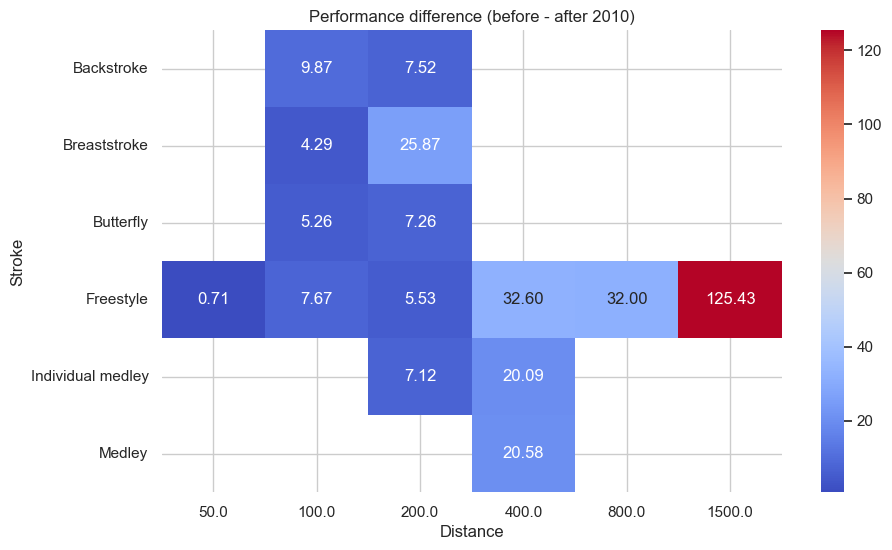

In [15]:
rows = []

for stroke in df['Stroke'].unique():
    for dist in df['Distance_float'].unique():
        
        before = df_before_2010[
            (df_before_2010['Stroke'] == stroke) & 
            (df_before_2010['Distance_float'] == dist)
        ]['Results']
        
        after = df_after_2010[
            (df_after_2010['Stroke'] == stroke) & 
            (df_after_2010['Distance_float'] == dist)
        ]['Results']
        
        if len(before) > 1 and len(after) > 1:
            rows.append({
                "Stroke": stroke,
                "Distance": dist,
                "Mean_before": before.mean(),
                "Mean_after": after.mean(),
                "Diff": before.mean() - after.mean(),
                "Count_before": len(before),
                "Count_after": len(after)
            })

df_summary = pd.DataFrame(rows)
df_summary = df_summary.sort_values(by="Diff", ascending=False)
df_summary = df_summary.round(4)

pivot = df_summary.pivot(index="Stroke", columns="Distance", values="Diff")


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Performance difference (before - after 2010)")

plt.savefig("images/supersuit_performance.png", dpi=300, bbox_inches="tight")
plt.show()

Trend BEFORE 2010: -0.1738 seconds/year
Trend AFTER 2010:  -0.0295 seconds/year


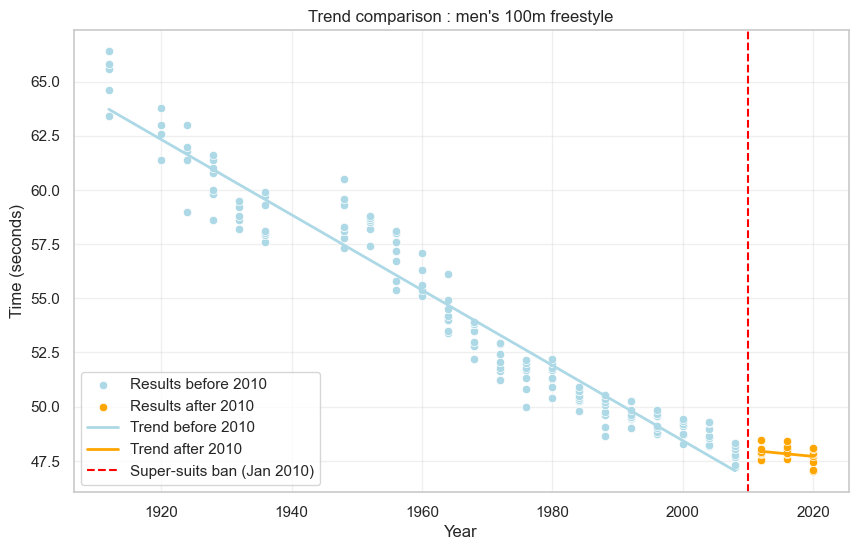

In [16]:
from sklearn.linear_model import LinearRegression

# Men's 100m freestyle
df_race = df[(df['Gender'] == 'Men') & 
             (df['Stroke'] == 'Freestyle') & 
             (df['Distance_float'] == 100)].dropna(subset=['Year', 'Results'])

df_before = df_race[df_race['Year'] < 2010]
df_after = df_race[df_race['Year'] >= 2010]

# X -> features, y -> target
# 2D array for X 
X_before = df_before[['Year']] 
y_before = df_before['Results']

X_after = df_after[['Year']]
y_after = df_after['Results']

# Linear Regression BEFORE 2010
model_before = LinearRegression()
model_before.fit(X_before, y_before)
slope_b = model_before.coef_[0]

# Linear Regression AFTER 2010
model_after = LinearRegression()
model_after.fit(X_after, y_after)
slope_a = model_after.coef_[0]

print(f"Trend BEFORE 2010: {slope_b:.4f} seconds/year")
print(f"Trend AFTER 2010:  {slope_a:.4f} seconds/year")

# Visualisation
plt.figure(figsize=(10, 6))

# Scatter plots
sns.scatterplot(data=df_before, x='Year', y='Results', color='lightblue', label='Results before 2010')
sns.scatterplot(data=df_after, x='Year', y='Results', color='orange', label='Results after 2010')

# Trend lines using model.predict()
plt.plot(df_before['Year'], model_before.predict(X_before), color='lightblue', linewidth=2, label='Trend before 2010')
plt.plot(df_after['Year'], model_after.predict(X_after), color='orange', linewidth=2, label='Trend after 2010')

# Vertical line for the ban
plt.axvline(x=2010, color='red', linestyle='--', label='Super-suits ban (Jan 2010)')

plt.title("Trend comparison : men's 100m freestyle")
plt.xlabel("Year")
plt.ylabel("Time (seconds)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("images/_linear_regression_supersuit_performance.png", dpi=300, bbox_inches="tight")
plt.show()

#### Relay vs Individual



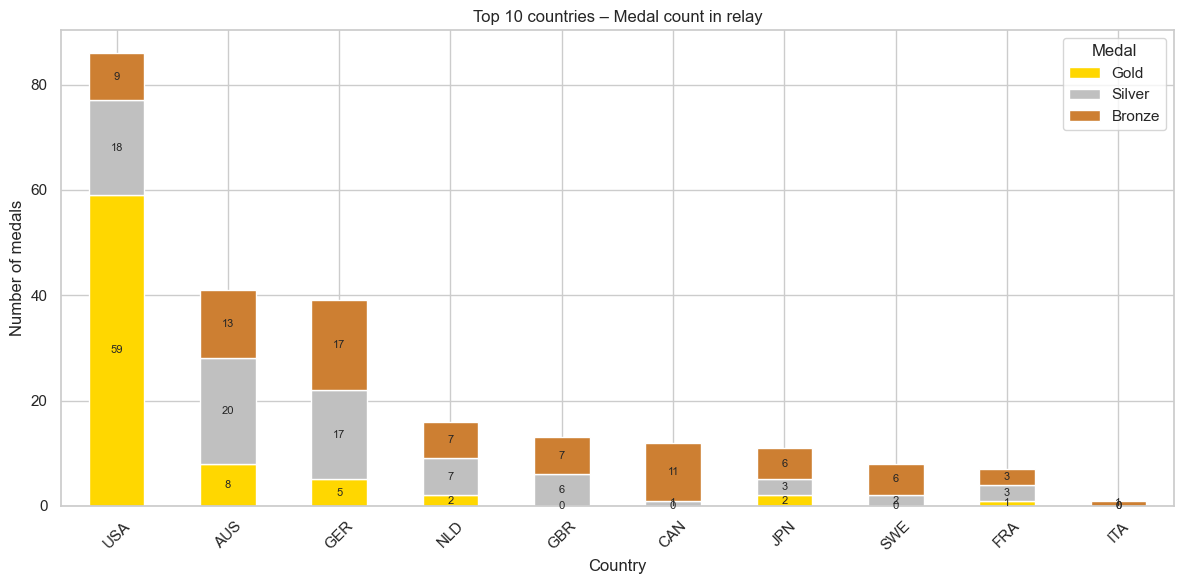

In [17]:
# who is dominant ?
df_individual = df[df["Relay?"]==0]
df_relay = df[df["Relay?"]==1]


medal_counts = (
    df_relay.groupby(['Team', 'Rank']) 
    .size()
    .reset_index(name='Count')
)

top10 = (
    medal_counts.groupby('Team')['Count']
    .sum()
    .nlargest(10)
    .index
)

df_top10_relay = medal_counts[medal_counts['Team'].isin(top10)]
df_pivot = df_top10_relay.pivot_table(index='Team', columns='Rank', values='Count', fill_value=0)
#row = country
#column = gold/silver/bronze
#value = medals sum count
df_pivot = df_pivot.reindex(columns=['Gold', 'Silver', 'Bronze'])
df_pivot = df_pivot.loc[df_pivot.sum(axis=1).sort_values(ascending=False).index] #sort countries from highest to most little count of medals
df_pivot = df_pivot.fillna(0)

ax = df_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color=['#FFD700', '#C0C0C0', '#CD7F32']
    
)



plt.title('Top 10 countries – Medal count in relay')
plt.ylabel('Number of medals')
plt.xlabel('Country')
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=8,label_type='center')  

plt.legend(title='Medal')
plt.tight_layout()
plt.show()

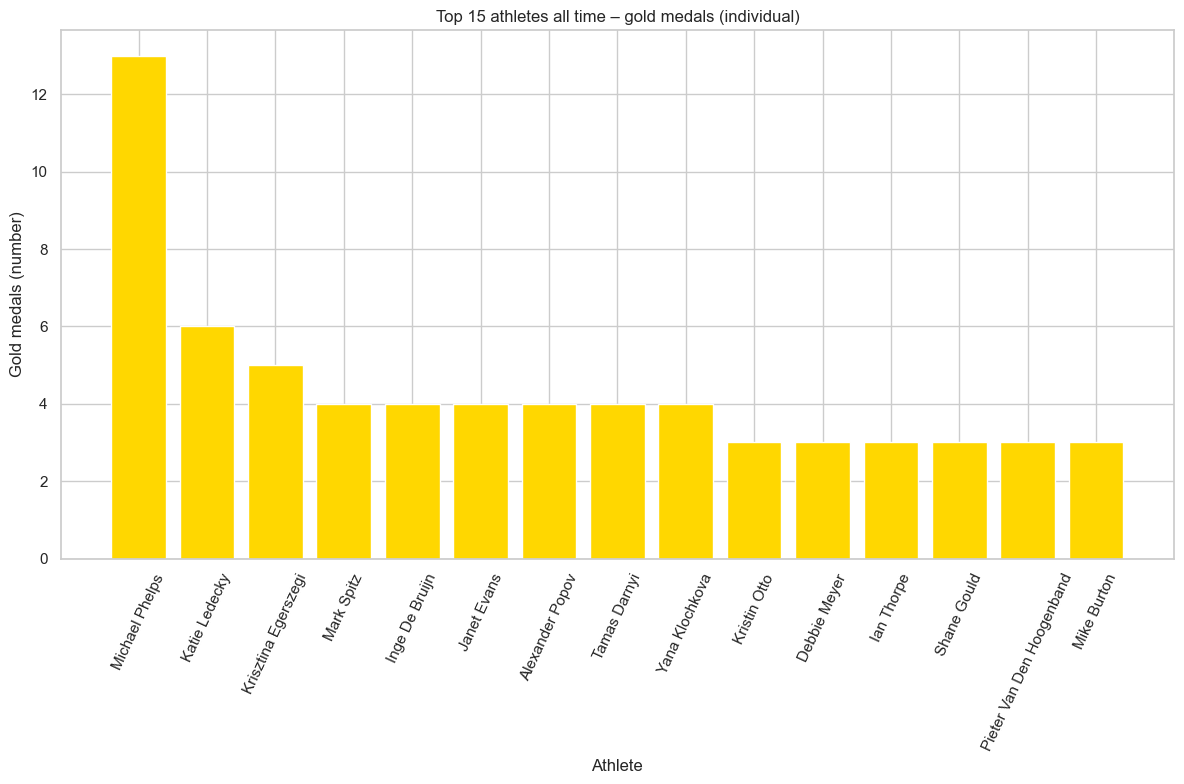

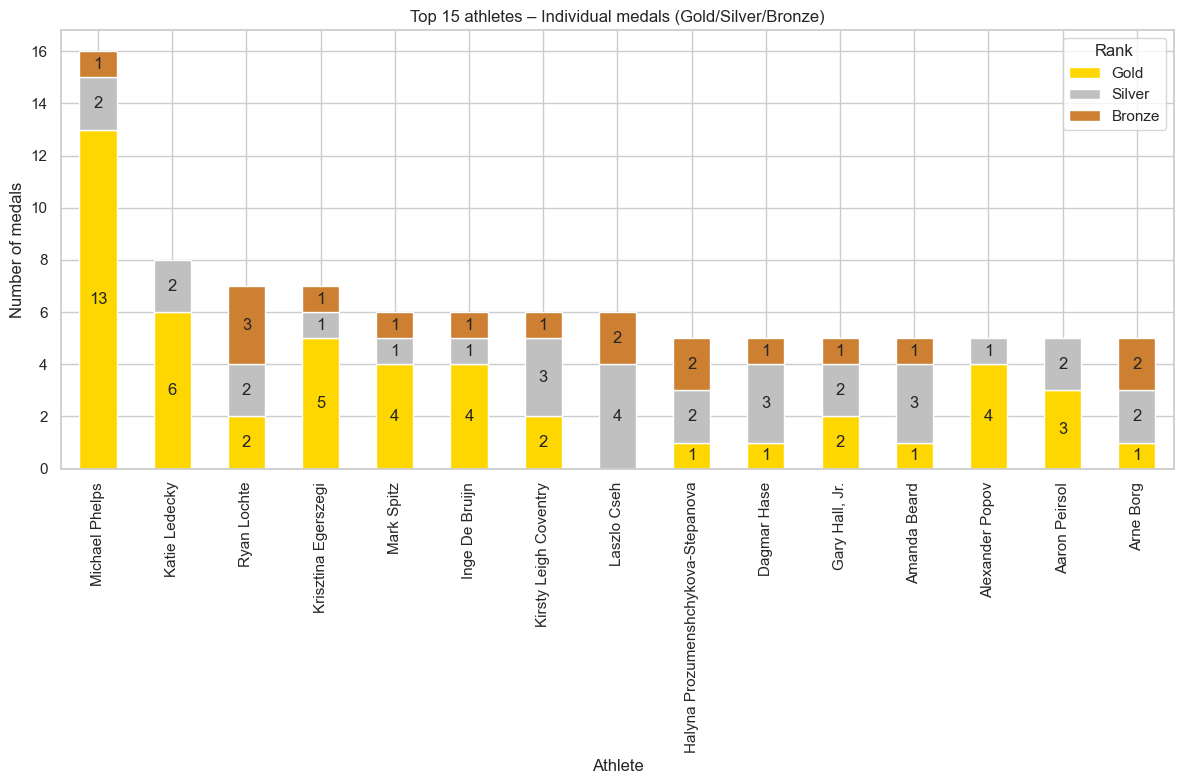

In [27]:
#only gold medals
df_individuals_medals_gold = df_individual[df_individual["Rank"]=="Gold"]
medal_gold_counts=(
    df_individuals_medals_gold.groupby("Athlete")
    .size()
    .reset_index(name = "Gold_medals_counts")
)
top_gold_athletes = medal_gold_counts.sort_values(by="Gold_medals_counts",ascending=False).head(15)
plt.figure(figsize=(12, 8))
plt.bar(top_gold_athletes["Athlete"],
        top_gold_athletes["Gold_medals_counts"], 
        color='#FFD700'
        )
plt.title("Top 15 athletes all time – gold medals (individual)")
plt.xlabel("Athlete")
plt.ylabel("Gold medals (number)")
plt.xticks(rotation=65)
plt.tight_layout()
plt.savefig("images/total_gold_medals_by_athletes.png",dpi=300,bbox_inches='tight')
plt.show()


#all medals (gold, silver, bronze)
df_individuals_medals = df_individual[df_individual["Rank"].isin(["Gold", "Silver", "Bronze"])]
medal_counts = (
    df_individuals_medals.groupby(["Athlete","Rank"])
    .size()
    .reset_index(name = "Individual_medals_counts")
)
top_athletes =(
    medal_counts.groupby("Athlete")["Individual_medals_counts"]
    .sum()
    .nlargest(15)
    .index
)
df_top_athletes = medal_counts[medal_counts["Athlete"].isin(top_athletes)]
df_pivot = df_top_athletes.pivot_table(
    index="Athlete",
    columns="Rank",
    values="Individual_medals_counts",
    fill_value=0
)
df_pivot = df_pivot.reindex(columns=["Gold", "Silver", "Bronze"])
df_pivot = df_pivot.loc[
    df_pivot.sum(axis=1).sort_values(ascending=False).index
]
ax = df_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 8),
    color=['#FFD700', '#C0C0C0', '#CD7F32']
)
plt.title("Top 15 athletes – Individual medals (Gold/Silver/Bronze)")
plt.xlabel("Athlete")
plt.ylabel("Number of medals")
plt.xticks(rotation=90)

max_val = df_pivot.sum(axis=1).max()
ax.set_yticks(np.arange(0, max_val + 2, 2))

for container in ax.containers:
    ax.bar_label(container, label_type='center', fmt=lambda x: int(x) if x > 0 else '')

plt.tight_layout()
plt.savefig("images/total_medals_by_athletes.png",dpi=300,bbox_inches='tight')
plt.show()


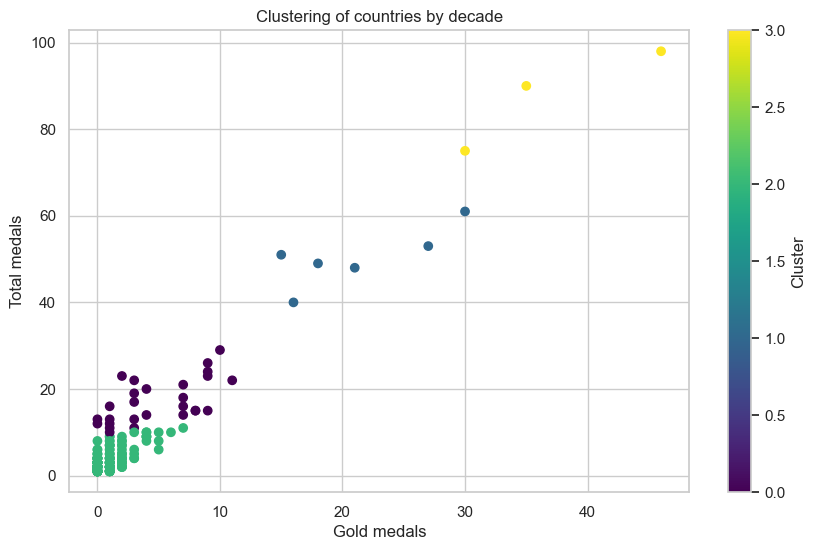

Rank          Gold     Silver     Bronze      Total       Score
Cluster                                                        
0         4.851852   5.666667   6.666667  17.185185   32.555556
1        21.166667  17.666667  11.500000  50.333333  110.333333
2         0.861702   1.122340   1.271277   3.255319    6.101064
3        37.000000  25.000000  25.666667  87.666667  186.666667


Cluster
0    [AUS, CAN, CHN, FRA, GBR, GDR, GER, HUN, JPN, ...
1                                      [AUS, GDR, USA]
2    [ANZ, ARG, AUS, AUT, BEL, BLR, BRA, BUL, CAN, ...
3                                                [USA]
Name: Team, dtype: object

In [22]:
#cluster

df["Decade"] = (df["Year"]//10)*10

df_medals = df[df["Rank"].isin(["Gold", "Silver", "Bronze"])]
medals = (
    df_medals.groupby(["Team", "Decade", "Rank"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
medals = medals.rename(columns={
    "Gold": "Gold",
    "Silver": "Silver",
    "Bronze": "Bronze"
})

medals["Total"] = medals[["Gold", "Silver", "Bronze"]].sum(axis=1)
medals["Score"] = medals["Gold"]*3 + medals["Silver"]*2 + medals["Bronze"]


from sklearn.preprocessing import StandardScaler

features = ["Gold", "Silver", "Bronze", "Total", "Score"]

X = medals[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
medals["Cluster"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10,6))

plt.scatter(
    medals["Gold"],
    medals["Total"],
    c=medals["Cluster"],
    cmap="viridis"
)

plt.xlabel("Gold medals")
plt.ylabel("Total medals")
plt.title("Clustering of countries by decade")

plt.colorbar(label="Cluster")
plt.savefig("images/clustering_medals.png",dpi=300,bbox_inches='tight')
plt.show()

cluster_profile = medals.groupby("Cluster")[features].mean()
print(cluster_profile)

medals.groupby("Cluster")["Team"].unique()


   Team                      Athlete  Medal_count  Total_medals  Share
5   BLR      Aliaksandra Herasimenia            3             3    1.0
23  HKG   Siobhan Bernadette Haughey            2             2    1.0
14  EGY         Taha Yussuf El Gamal            1             1    1.0
11  CRO                Duje Draganja            1             1    1.0
33  NOR              Sara Nordenstam            1             1    1.0
29  KOR                Tae-Hwan Park            4             4    1.0
28  KAZ             Dmitriy Balandin            2             2    1.0
25  IRL         Michelle Marie Smith            4             4    1.0
53  VEN  Rafael Antonio Vidal Castro            1             1    1.0
42  SLO                Sara Isakovic            1             1    1.0


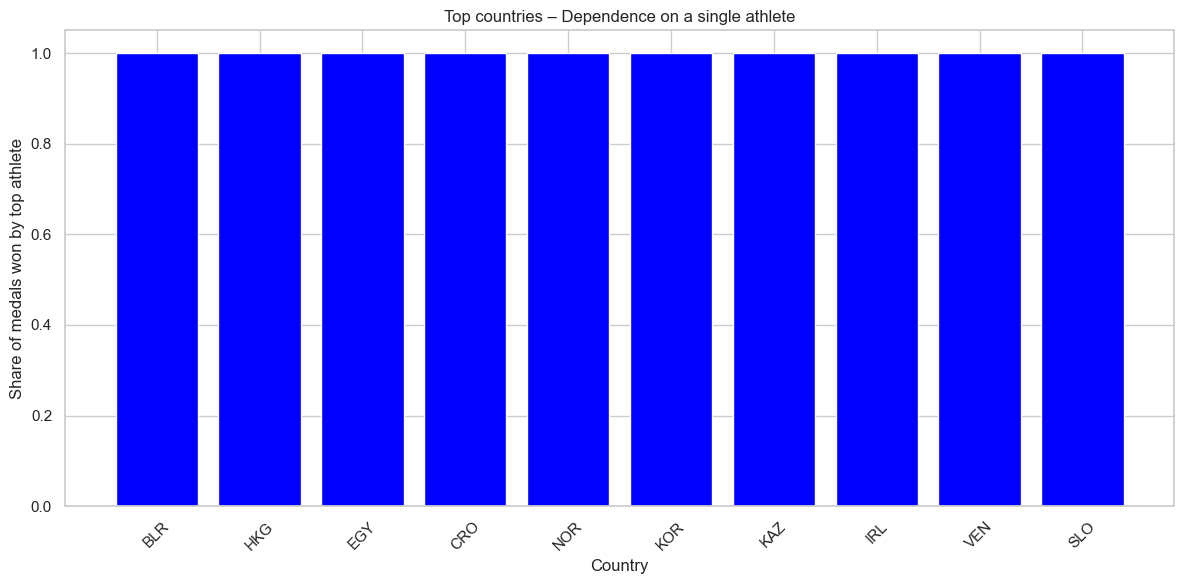

In [26]:
#superstar effect -> Is a country dependent on certain athletes?

df_individuals_medals = df_individual[df_individual["Rank"].isin(["Gold", "Silver", "Bronze"])]

#medals by athletes & country
athlete_medals = (
    df_individuals_medals.groupby(["Team", "Athlete"])
    .size()
    .reset_index(name = "Medal_count")
    )

#total medals per country
country_totals = (
    athlete_medals.groupby("Team")["Medal_count"]
    .sum()
    .reset_index(name="Total_medals")
)

#superstar of a country
top_athletes = (
    athlete_medals.sort_values(["Team", "Medal_count"], ascending=[True, False])
    .drop_duplicates("Team")
)
#calculation of superstar effect
superstar_effect = top_athletes.merge(country_totals, on="Team")

superstar_effect["Share"] = (
    superstar_effect["Medal_count"] / superstar_effect["Total_medals"]
)

#dependant countries
top_dependency = superstar_effect.sort_values(by="Share", ascending=False).head(10)
print(top_dependency)

plt.figure(figsize=(12,6))

plt.bar(
    top_dependency["Team"],
    top_dependency["Share"],
    color="blue"
)

plt.title("Top countries – Dependence on a single athlete")
plt.ylabel("Share of medals won by top athlete")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/dependance.png",dpi=300,bbox_inches='tight')
plt.show()


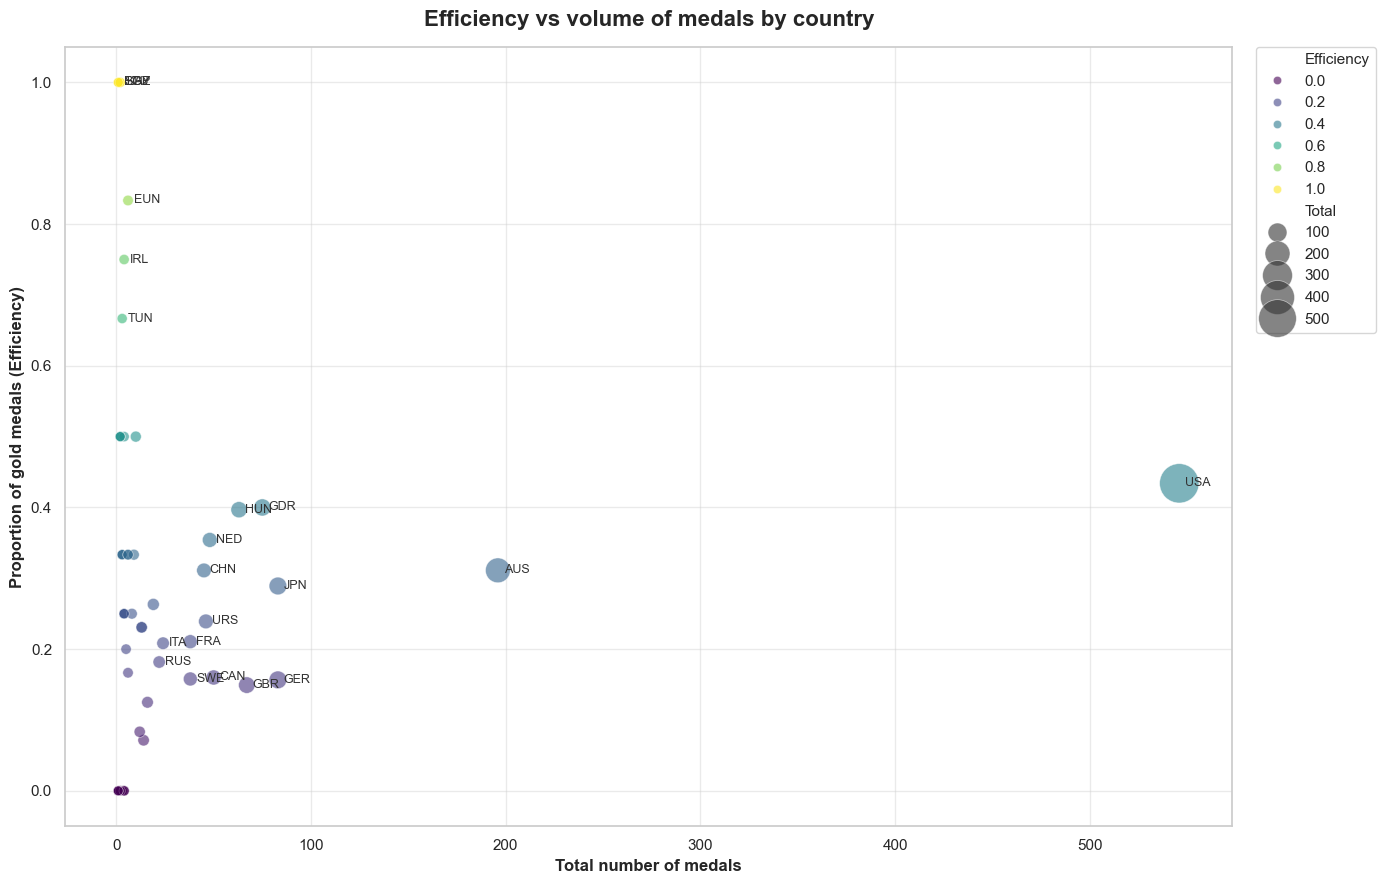

In [25]:
# efficiency VS volume

# Calculate total medals and gold medals per country
country_totals = (
    df_medals.groupby("Team")
    .agg(
        Total=("Rank", "count"), # count number of medals
        Gold=("Rank", lambda x: (x == "Gold").sum()) # count number of gold medals
    )
    .reset_index()
)

# Efficiency = ratio of Gold / Total medals
country_totals["Efficiency"] = country_totals["Gold"] / country_totals["Total"]

# Set a cleaner theme
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 9))

# Use a bubble chart style: size varies by total, color by efficiency
scatter = sns.scatterplot(
    data=country_totals,
    x="Total", 
    y="Efficiency", 
    size="Total",
    sizes=(50, 800),       
    hue="Efficiency",
    palette="viridis",     
    alpha=0.6,
    linewidth=0.5
)

# Add labels only for remarkable points (Total > 20 or Efficiency > 50%)
for i, row in country_totals.iterrows():
    if row["Total"] > 20 or row["Efficiency"] > 0.5:
        plt.text(
            row["Total"] + 3,  # Adjusted offset
            row["Efficiency"], 
            row["Team"], 
            fontsize=9,
            va="center",
            color="#333333"
        )

# Formatting axes, title, and legend
plt.xlabel("Total number of medals", fontsize=12, fontweight="bold")
plt.ylabel("Proportion of gold medals (Efficiency)", fontsize=12, fontweight="bold")
plt.title("Efficiency vs volume of medals by country", fontsize=16, fontweight="bold", pad=15)

# Move the legend outside the plot to avoid overlapping
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("images/efficiency.png", dpi=300, bbox_inches='tight')
plt.show()


# filter out countries with very few medals to make the metric meaningful
top_efficiency = country_totals[country_totals["Total"]>=10].sort_values(
    by=["Efficiency", "Total"], ascending=[False, False]
).head(15)

# Format the efficiency column for display
top_efficiency["Efficiency_str"] = (top_efficiency["Efficiency"] * 100).round(2).astype(str) + "%"

# Plotly Table that is clean and easy to export or screenshot for a report
fig_table = go.Figure(data=[go.Table(
    header=dict(
        values=["<b>Country</b>", "<b>Total Medals</b>", "<b>Gold Medals</b>", "<b>Efficiency</b>"],
        fill_color="#457b9d",
        font=dict(color="white", size=14),
        align="center",
        height=35
    ),
    cells=dict(
        values=[
            top_efficiency["Team"],
            top_efficiency["Total"],
            top_efficiency["Gold"],
            top_efficiency["Efficiency_str"]
        ],
        fill_color=[["#f1f5f9", "white"] * 8],
        font=dict(color="#333333", size=13),
        align="center",
        height=30
    )
)])

fig_table.update_layout(
    title_text="<b>Top 15 Most Efficient Nations (Min. 10 Medals)</b>",
    title_x=0.5,
    margin=dict(l=20, r=20, t=50, b=20),
    height=550
)

#fig_table.write_image("images/table_efficiency.png")
fig_table.show()